### Notebook to compare ORCESTRA sounding statistics from different sources.

James Ruppert  
jruppert@ou.edu  
2/10/25

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from thermo_functions import *
from orcestra_read_data import *
from time_series_diag import *
import seaborn as sns
from vertical_int import *
from dynamo_read_data import *
from tqdm.notebook import tqdm_notebook
import warnings
warnings.filterwarnings('ignore')

### Read in data

#### Data from IPFS server

In [95]:
# GPS water vapor
path = "METEOR/GNSS_IWV.zarr"
var = "iwv"
cwv_gps, times_gps = get_ipfs_data(path, var)

# Sun photometer data
path = "METEOR/Sunphotometer/AOD/Meteor_24_0_all_points.lev20.zarr"
var = "water_vapor(cm)"
photom, times_photom = get_ipfs_data(path, var)
photom*=10 # Convert cm to mm

# HALO dropsondes
snd_halo = read_halo_soundings_lev3()
nt_halo = len(snd_halo['times'])
min_pres_halo = np.full(nt_halo, np.nan)
for isnd in range(nt_halo):
    min_pres_halo[isnd] = np.nanmin(snd_halo['p'][isnd,:]*1e-2) # Pa --> hPa

# BCO soundings
snd_bco = read_soundings(platform='BCO')
# SAL soundings
snd_sal = read_soundings(platform='INMG')
# Meteor soundings
snd_meteor = read_soundings(platform='RV_Meteor')
# snd_vars = list(snd_meteor.keys())[2:] # retain only 2-d variables in list

# DYNAMO soundings
snd_dyn = read_dynamo_soundings()

# Mask soundings that don't reach 100 hPa
# snd_halo, min_pres_halo = mask_soundings(snd_halo, p_threshold=100)
# snd_bco, min_pres_bco = mask_soundings(snd_bco, p_threshold=100)
# snd_sal, min_pres_sal = mask_soundings(snd_sal, p_threshold=100)
snd_meteor, min_pres_meteor = mask_soundings(snd_meteor, p_threshold=100)
# min_pres_dyn = {}
# for isnd in snd_dyn.keys():
#     snd_dyn[isnd], min_pres_dyn[isnd] = mask_soundings(snd_dyn[isnd], p_threshold=100)

#### Local data

In [96]:
# Radiometer data
cwv_rdm, times_rdm = read_bowtie_radiometer()

# ERA5 IWV data
# alongtrack, alongsonde
cwv_era5v1, cwv_era5v2, times_era5, times_sonde_era5 = read_era5_shiptrack_iwv()

In [97]:
# Read in cloud/rain conditions
# based on rain gauge, cielometer, cloud radar
cloud_mask_ds = xr.open_dataset('data/BOWTIE_sky_condition_classification.nc')
cloud_mask_ds
cloud_mask = cloud_mask_ds['classification_sky'].values
times_cloud_mask = cloud_mask_ds['time'].values
cloud_mask_ds.close()

# Interpolates the cloud mask to match the times of the input soundings.
def interpolate_cloud_mask(times_cloud_mask, cloud_mask, times_output):
    cloud_mask_interp = np.full(len(times_output), np.nan)
    for itime in tqdm_notebook(range(len(times_output))):
        time_diff = np.abs(times_cloud_mask.astype('datetime64[ns]') - times_output[itime].astype('datetime64[ns]'))
        closest_index = np.argmin(time_diff)
        cloud_mask_interp[itime] = cloud_mask[closest_index]
    return cloud_mask_interp

### Vertically integrate water vapor

#### Final formula:

Use specific humidity $q$ for both $\rho$ and IWV.

$$\text{IWV} = \int_{z_0}^{z_t} q \rho \, dz$$

$$\rho = \frac{p}{R_d T \left[1 + q\left(\frac{R_v}{R_d} - 1\right)\right]}$$

In [98]:
# CWV aka IWV aka PW
cwv_meteor = vert_integral(snd_meteor)
cwv_meteor_30m = vert_integral(snd_meteor, zbase=30)
# cwv_hydro = vert_integral_hydro(snd_meteor)
cwv_halo = vert_integral(snd_halo, set_nans=False)
# cwv_halo_hydro = vert_integral_hydro(snd_halo)
cwv_bco = vert_integral(snd_bco)
cwv_sal = vert_integral(snd_sal)
cwv_dyn = {}
for isnd in snd_dyn.keys():
    cwv_dyn[isnd] = vert_integral(snd_dyn[isnd])

#### Integral comparisons

In [69]:
# def vert_integral_old(invar, tmpk, mr, p, hght, minpres=0):
#     rho = density_moist(tmpk, mr, p) # kg/m3
#     dz = hght[1]-hght[0] # m
#     invar_masked = np.copy(invar)
#     invar_masked[np.where(p < minpres)] = np.nan
#     var_int = np.nansum(invar_masked*rho, axis=1)*dz
#     var_int[ np.where(np.isnan(soundings['p'][:,5])) ] = np.nan
#     return var_int
def vert_integral_hydro_sh(data, set_nans=True):
    p = np.ma.filled(data['p'], np.nan)
    try:
        sh = data['sh']
        mr = sh2mixr(sh)
    except:
        mr = data['mr']
        sh = mixr2sh(mr)
    cwv = np.nansum(-sh*np.gradient(p, axis=1), axis=1)/9.81
    # var_int[ np.where(np.isnan(soundings['p'][:,5])) ] = np.nan
    if set_nans:
        nans = np.where(np.isnan(p[:,5]))
        cwv[nans] = np.nan
    return cwv

def vert_integral_mr(data, zbase=0, set_nans=True):
    p = np.ma.filled(data['p'], np.nan)
    t = np.ma.filled(data['tmpk'], np.nan)
    hght = data['hght']
    if hght.ndim == 1:
        iz = np.where(hght >= zbase)[0]
        hght = np.repeat(hght[np.newaxis,:], p.shape[0], axis=0)
    else:
        iz = np.where(hght[0,:] >= zbase)[0]
    try:
        sh = data['sh']
        mr = sh2mixr(sh)
    except:
        mr = data['mr']
        sh = mixr2sh(mr)
    # rho = density_moist(t, sh, p) # kg/m3
    rd=287.04
    rv=461.5
    eps_r=rv/rd
    # The two forms of rho below are identical, just using r vs q
    # rho = p / ( rd * t * (1. + mr*eps_r)/(1.+mr) )
    # Below is the form of Schulz and Stevens (2018)
    rho = p / ( rd * t * (1 + sh*(eps_r - 1)) )
    cwv = np.trapezoid(mr[:,iz] * rho[:,iz], hght[:,iz], axis=1)
    # cwv = np.nansum((rho[:,iz] * sh[:,iz] * np.gradient(hght[:,iz], axis=1)), axis=1)
    # Replace NaNs
    if set_nans:
        nans = np.where(np.isnan(p[:,5]))
        cwv[nans] = np.nan
    return cwv

# Below is identical to latest/selected method
def vert_integral_sh(data, zbase=0, set_nans=True):
    p = np.ma.filled(data['p'], np.nan)
    t = np.ma.filled(data['tmpk'], np.nan)
    hght = data['hght']
    if hght.ndim == 1:
        iz = np.where(hght >= zbase)[0]
        hght = np.repeat(hght[np.newaxis,:], p.shape[0], axis=0)
    else:
        iz = np.where(hght[0,:] >= zbase)[0]
    try:
        sh = data['sh']
        # mr = sh2mixr(sh)
    except:
        mr = data['mr']
        sh = mixr2sh(mr)
    # rho = density_moist(t, sh, p) # kg/m3
    rd=287.04
    rv=461.5
    eps_r=rv/rd
    # The two forms of rho below are identical, just using r vs q
    # rho = p / ( rd * t * (1. + mr*eps_r)/(1.+mr) )
    # Below is the form of Schulz and Stevens (2018)
    rho = p / ( rd * t * (1 + sh*(eps_r - 1)) )
    cwv = np.trapezoid(sh[:,iz] * rho[:,iz], hght[:,iz], axis=1)
    # cwv = np.nansum((rho[:,iz] * sh[:,iz] * np.gradient(hght[:,iz], axis=1)), axis=1)
    # Replace NaNs
    if set_nans:
        nans = np.where(np.isnan(p[:,5]))
        cwv[nans] = np.nan
    return cwv

In [70]:
cwv_mr = vert_integral_mr(snd_meteor)
cwv_sh = vert_integral_sh(snd_meteor) # latest method
cwv_sh_30m = vert_integral_sh(snd_meteor, zbase=30) # latest method, 30 m base height
cwv_hydro_sh = vert_integral_hydro_sh(snd_meteor)

#### Helene's code

In [71]:
def q2vmr(q):
    import constants
    Md = constants.molar_mass_dry_air
    Mw = constants.molar_mass_water
    return q / ((1 - q) * Mw / Md + q)
def mr2vmr(mr):
    import constants
    Md = constants.molar_mass_dry_air
    Mw = constants.molar_mass_water
    return mr / (mr + Mw / Md)

def integrate_water_vapor(p, q, T=None, z=None, axis=0):
    """Returns the integrated water vapor for given specific humidity
    Args:
        p: pressure in Pa
        either: (hydrostatic)
            q: specific humidity
        or: (non-hydrostatic)
            q: specific humidity
            T: temperature
            z: height

    """

    def density(p, T, mr, eps=None):
        """
        returns density for given pressure, temperature and R
        """
        import constants
        Rd = constants.gas_constant_dry_air
        if eps is None:
            eps=18.0160/28.9660
            # eps = constants.eps1
        return eps * p * (1 + mr) / (Rd * T * (mr + eps))  # water vapor density

    def integrate_column(y, x, axis=0):
        if np.all(x[:-1] >= x[1:]):
            # return -np.trapz(y, x, axis=axis)
            return -np.trapezoid(y, x, axis=axis)
        else:
            # return np.trapz(y, x, axis=axis)
            return np.trapezoid(y, x, axis=axis)

    if T is None and z is None:
        # Calculate IWV assuming hydrostatic equilibrium.
        g = 9.81#constants.gravity_earth
        return -integrate_column(q, p, axis=axis) / g
    elif T is None or z is None:
        raise ValueError(
            "Pass both `T` and `z` for non-hydrostatic calculation of the IWV."
        )
    else:
        # Integrate the water vapor mass density for non-hydrostatic cases.
        Rv = 461.5  # J/kg/K
        # rho = density(p, T, constants.Rv)  # water vapor density
        rho = density(p, T, Rv)  # water vapor density
        # vmr = q2vmr(q)
        # vmr = q / ((1 - q) * constants.molar_mass_h2o / constants.md + q)
        vmr = q2vmr(q)

    return integrate_column(vmr * rho, z, axis=axis)

def get_cwv_helene(data):
    p = data['p']
    try:
        q = data['q']
    except:
        q = mixr2sh(data['mr'])
    T = data['tmpk']
    z = np.repeat(data['hght'][np.newaxis,:], p.shape[0], axis=0)
    return integrate_water_vapor(np.transpose(p), np.transpose(q), T=np.transpose(T), z=np.transpose(z), axis=0)

cwv_helene = get_cwv_helene(snd_meteor)
cwv_halo_helene = get_cwv_helene(snd_halo)

---
### Plotting

#### Plotting functions

In [72]:
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 12}

rc('font', **font)

In [73]:
def plot_cwv_kde(legends, cwvs, title=''):

    # sns.set_theme(style="darkgrid", rc={'xtick.bottom': True, 'ytick.left': True,})
    sns.set_theme(style="ticks", rc={'xtick.bottom': True, 'ytick.left': True, "axes.spines.right": False, "axes.spines.top": False})
    # sns.set_theme(style="dark")

    fig_x = 6
    fig_y = 4
    fig, ax = plt.subplots(1,1, figsize=(fig_x,fig_y), layout='constrained', squeeze=True)
    plt.suptitle(title)
    ax.set_ylabel('Density')
    ax.set_xlabel('kg/m$^2$')
    ax.set_xlim(30, 76)

    default_colors = sns.color_palette()
    means = []

    # Save first mean to get the difference
    mean_i0 = np.nanmean(cwvs[0])

    for i, (icwv, legend) in enumerate(zip(cwvs, legends)):
        # Calculate the median values
        mean = np.nanmean(icwv)
        means.append(mean)
        diff_from_meteor = mean - mean_i0
        diff_from_meteor = str(np.round(diff_from_meteor,2))
        if i > 0:
            legend = legend+r' ($\Delta= $'+diff_from_meteor+')'
        else:
            legend = legend+r' (N = '+str(np.sum(np.isfinite(icwv)))+')'
        color = default_colors[i]
        # Kernel Density Estimate (KDE) plots
        kde = sns.kdeplot(icwv, ax=ax, label=legend, fill=True, common_norm=True, color=color)
        # print("Mean: ", mean, 'kg/m^2')
        # Plot vertical lines at the median values
        lw = 1.0
        ax.axvline(x=mean, color=color, linewidth=lw)

    sns.despine(offset=10,ax=ax)#, left=True, bottom=False)
    ax.legend(fontsize='small', loc='upper left', frameon=False)
    plt.show()
    # Save figure
    fig.savefig('cwv_kde_methods.png', dpi=300, bbox_inches='tight')
    plt.close()
    return None

In [74]:
def plot_cwv_kde_cm(legends, cwvs_nested, cm_tags):

    # sns.set_theme(style="darkgrid", rc={'xtick.bottom': True, 'ytick.left': True,})
    sns.set_theme(style="ticks", rc={'xtick.bottom': True, 'ytick.left': True, "axes.spines.right": False, "axes.spines.top": False})
    # sns.set_theme(style="dark")

    fig_x = 6
    fig_y = 10
    nrows = len(cwvs_nested)
    fig, ax = plt.subplots(nrows,1, figsize=(fig_x,fig_y), layout='constrained', squeeze=True)
    # plt.suptitle(title)
    for i, iax in enumerate(ax):
        iax.set_title(cm_tags[i])
        iax.set_ylabel('Density')
        sns.despine(offset=10,ax=iax)#, left=True, bottom=False)
        iax.set_xlim(30, 76)

    default_colors = sns.color_palette('muted', n_colors=len(legends))
    # default_colors = sns.color_palette()

    for (iax, cwv_group) in zip(ax, cwvs_nested):

        # Save meteor mean to get the difference
        meteor_mean = np.nanmean(cwv_group[0])

        for i, (icwv, legend) in enumerate(zip(cwv_group, legends)):
            mean = np.nanmean(icwv)
            diff_from_meteor = mean - meteor_mean
            diff_from_meteor = str(np.round(diff_from_meteor,2))
            if i > 0:
                legend = legend+r' ($\Delta= $'+diff_from_meteor+')'
            else:
                legend = legend+r' (N = '+str(np.sum(np.isfinite(icwv)))+')'
            # Kernel Density Estimate (KDE) plots
            color = default_colors[i]
            # if i == 0:
            #     color='black'
            kde = sns.kdeplot(icwv, ax=iax, label=legend, fill=True, common_norm=True, color=color)
            # Plot vertical line
            lw = 0.7
            iax.axvline(x=mean, color=color, linewidth=lw)

    # Remove tick numbers from all but the last axis
    for iax in ax[:-1]:
        iax.tick_params(labelbottom=False)

    # ax[0].legend(loc='upper left', fontsize='small')
    for iax in ax:
        iax.set_xlabel('')
        iax.legend(fontsize='small', loc='upper left', frameon=False)
    ax[-1].set_xlabel('IWV [kg/m$^2$]')
    # plt.legend()
    plt.show()
    # Save figure
    fig.savefig('cwv_kde_cm.png', dpi=300, bbox_inches='tight')
    plt.close()
    return None

In [75]:
def plot_var_scatter(legends, vars_plot, xtitle='', title='', do_legend=True):

    sns.set_theme(style="darkgrid", rc={'xtick.bottom': True, 'ytick.left': True,})
    # sns.set_theme(style="ticks", rc={'xtick.bottom': True, 'ytick.left': True})#, "axes.spines.right": False, "axes.spines.top": False})
    # sns.set_theme(style="dark")

    fig_x = 3
    fig_y = 4
    fig, ax = plt.subplots(1, 1, figsize=(fig_x, fig_y), layout='constrained', squeeze=True)
    plt.suptitle(title)
    ax.set_ylabel(xtitle)

    default_colors = sns.color_palette()

    # Plot raw CWV data
    for i, (ivar, legend) in enumerate(zip(vars_plot, legends)):
        ax.scatter(np.repeat(i, len(ivar)), ivar, label=legend, color=default_colors[i])

    # Set x-axis ticks and labels
    ax.set_xticks(range(len(legends)))
    ax.set_xticklabels(legends)

    # Adjust xlim to remove excess white space
    ax.set_xlim(-0.5, len(legends) - 0.5)

    if do_legend:
        # Add legend
        plt.legend()

    plt.show()
    return None

In [76]:
def get_vars_skewt(sounding, it):
    from metpy.units import units
    from metpy.calc import dewpoint_from_specific_humidity
    p = sounding['p'][it,:].data * 1e-2
    T = (sounding['tmpk'][it,:].data - 273.15)
    try:
        sh = mixr2sh(sounding['mr'][it,:].data)
    except:
        sh = sounding['q'][it,:].data
    # Apply units for MetPy functions
    p *= units.hPa
    T *= units.degC
    sh *= units.dimensionless
    Td = dewpoint_from_specific_humidity(p, T, sh)
    return p, T, Td

In [77]:
def plot_sounding(sounding, t_ind, title=''):

    from metpy.plots import Hodograph, SkewT

    # sns.set_theme(style="darkgrid", rc={'xtick.bottom': True, 'ytick.left': True,})
    sns.set_theme(style="ticks", rc={'xtick.bottom': True, 'ytick.left': True})#, "axes.spines.right": False, "axes.spines.top": False})
    # sns.set_theme(style="dark")

    fig_x = 10
    fig_y = 7
    fig = plt.figure(figsize=(fig_x,fig_y), layout='constrained')

    skew = SkewT(fig, aspect=80)
    p, T, Td = get_vars_skewt(sounding, t_ind)
    skew.plot(p, T, 'r', linewidth=2)
    skew.plot(p, Td, 'g', linewidth=2)
    # skew.plot_barbs(p, u, v)

    # Add the relevant special lines
    # skew.plot_dry_adiabats()
    skew.plot_moist_adiabats()
    # skew.plot_mixing_lines()
    # Set temperature range
    skew.ax.set_xlim(-40, 40)  # Adjust the temperature range as needed
    skew.ax.set_xlabel('T [$^\circ$C]')
    skew.ax.set_ylabel('P [hPa]')

    fig.suptitle(title)

    plt.show()

    return None

In [78]:
def plot_sounding_comparison(soundings_plot, t_ind, title):

    from metpy.plots import Hodograph, SkewT

    # sns.set_theme(style="darkgrid", rc={'xtick.bottom': True, 'ytick.left': True,})
    sns.set_theme(style="ticks", rc={'xtick.bottom': True, 'ytick.left': True})#, "axes.spines.right": False, "axes.spines.top": False})
    # sns.set_theme(style="dark")

    fig_x = 10
    fig_y = 6
    fig = plt.figure(figsize=(fig_x,fig_y), layout='constrained')

    skew = SkewT(fig, aspect=110)

    # Add the relevant special lines
    # skew.plot_dry_adiabats()
    skew.plot_moist_adiabats()
    # skew.plot_mixing_lines()

    # Set temperature range
    skew.ax.set_xlim(-40, 40)  # Adjust the temperature range as needed

    skew.ax.set_ylabel('P [hPa]')
    skew.ax.set_xlabel('T [$^\circ$C]')
    fig.suptitle(title)

    # for i, (i_sounding, i_t_ind) in enumerate(zip(soundings_plot, t_ind)):

    lw = 3.0
    p, T, Td = get_vars_skewt(soundings_plot[0], t_ind[0])
    skew.plot(p, T, 'r', linewidth=lw)
    skew.plot(p, Td, 'g', linewidth=lw)
    # skew.plot_barbs(p, u, v)

    lw = 1.0
    p, T, Td = get_vars_skewt(soundings_plot[1], t_ind[1])
    skew.plot(p, T, 'b', linewidth=lw, color='black')
    skew.plot(p, Td, 'c', linewidth=lw, color='black')
    # skew.plot_barbs(p, u, v)

    plt.show()
    return None

#### Compare integration approaches

In [79]:
# cwv_zint_mr = vert_integral_old(soundings['mr'], soundings['tmpk'], soundings['mr'], soundings['p'],
#                     soundings['hght'], minpres=minpres) # mm or kg/m2
# mr = soundings['mr']
# sh = mr / (1 + mr)
# cwv_zint_sh = vert_integral_old(sh, soundings['tmpk'], soundings['mr'], soundings['p'],
#                     soundings['hght'], minpres=minpres) # mm or kg/m2
# cwv_pint_sh = vert_integral_new(sh, soundings['p'], minpres=minpres) # mm or kg/m2
# cwv_pint_mr = cwv

In [80]:
def mean_comparison(cwvs, legends):
    for i, icwv in enumerate(cwvs):
        print('Mean CWV for', legends[i], ':', np.nanmean(icwv).round(3), 'kg/m^2')
    print("Difference between means:" , np.abs(np.nanmean(cwvs[0]) - np.nanmean(cwvs[1])).round(3), 'kg/m^2')
    return None

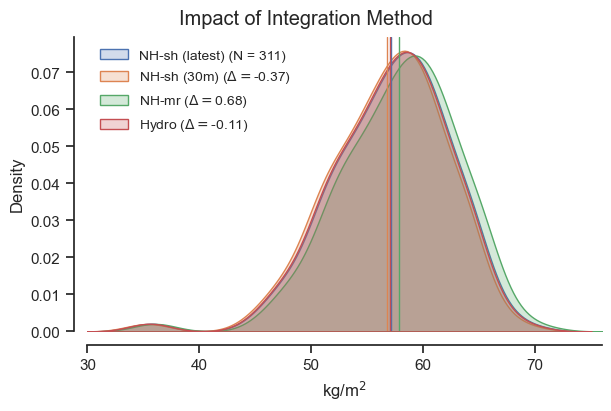

Mean CWV for NH-sh (latest) : 57.177 kg/m^2
Mean CWV for NH-sh (30m) : 56.81 kg/m^2
Mean CWV for NH-mr : 57.86 kg/m^2
Mean CWV for Hydro : 57.072 kg/m^2
Difference between means: 0.368 kg/m^2



In [81]:
legends = ['NH-sh (latest)', 'NH-sh (30m)', 'NH-mr', 'Hydro']
cwvs = [cwv_sh, cwv_sh_30m, cwv_mr, cwv_hydro_sh]
plot_cwv_kde(legends, cwvs, title='Impact of Integration Method')
mean_comparison(cwvs, legends)

print()

# legends = ['IWV-nonhyd', 'IWV-hydro']
# cwvs = [cwv_halo, cwv_halo_hydro]
# plot_cwv_kde(legends, cwvs, title='Hydro vs. non-hydro: HALO')
# mean_comparison(cwvs, legends)

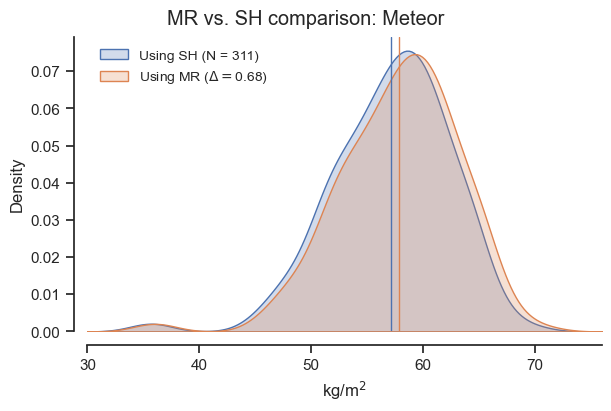

Mean CWV for Using SH : 57.177 kg/m^2
Mean CWV for Using MR : 57.86 kg/m^2
Difference between means: 0.683 kg/m^2


In [82]:
legends = ['Using SH', 'Using MR']
cwvs = [cwv_meteor, cwv_mr]
plot_cwv_kde(legends, cwvs, title='MR vs. SH comparison: Meteor')
mean_comparison(cwvs, legends)

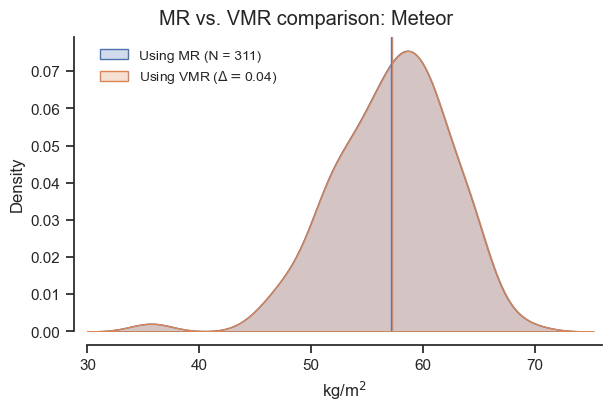

Mean CWV for Using MR : 57.177 kg/m^2
Mean CWV for Using VMR : 57.22 kg/m^2
Difference between means: 0.043 kg/m^2



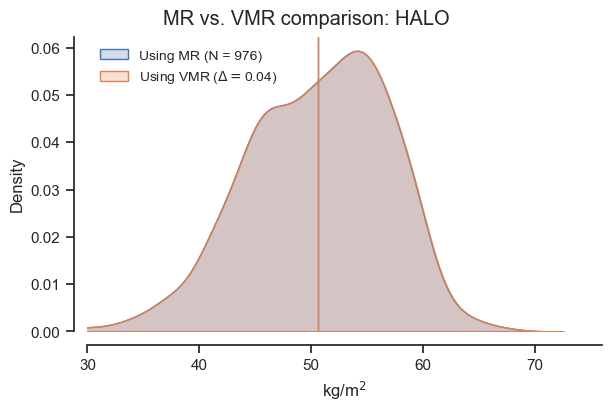

Mean CWV for Using MR : 50.616 kg/m^2
Mean CWV for Using VMR : 50.654 kg/m^2
Difference between means: 0.038 kg/m^2


In [83]:
legends = ['Using MR', 'Using VMR']
cwvs = [cwv_meteor, cwv_helene]
plot_cwv_kde(legends, cwvs, title='MR vs. VMR comparison: Meteor')
mean_comparison(cwvs, legends)

print()

legends = ['Using MR', 'Using VMR']
cwvs = [cwv_halo, cwv_halo_helene]
plot_cwv_kde(legends, cwvs, title='MR vs. VMR comparison: HALO')
mean_comparison(cwvs, legends)

In [84]:
# legends = ['Using VMR', 'FromData']
# cwvs = [cwv_halo_helene, snd_halo['iwv']]
# plot_cwv_kde(legends, cwvs, title='HALO comparison of sources')
# mean_comparison(cwvs, legends)

In [85]:
# legends = ['Calculated - FromData']
# cwvs = [cwv_halo_helene - snd_halo['iwv']]
# print("Median: ",np.median(cwvs).round(2))
# plot_cwv_kde(legends, cwvs, title='Difference')
# # mean_comparison(cwvs, legends)
# print('Mean difference:', np.nanmean(cwvs).round(3), 'kg/m^2')

#### All dataset comparison

In [88]:
# Exclude Mindelo data - select times after 16 Aug 2024
# t_start = np.datetime64('2024-08-16T08:00:00')
t_start = np.datetime64('2024-08-17T00:00:00')
t_ind_snd = np.where(snd_meteor['times'] >= t_start)[0]
t_ind_rdm = np.where(times_rdm >= t_start)[0]
t_ind_photom = np.where(times_photom >= t_start)[0]
t_ind_gps = np.where(times_gps >= t_start)[0]
t_ind_era5v1 = np.where(times_era5 >= t_start)[0]
t_ind_era5v2 = np.where(times_sonde_era5 >= t_start)[0]

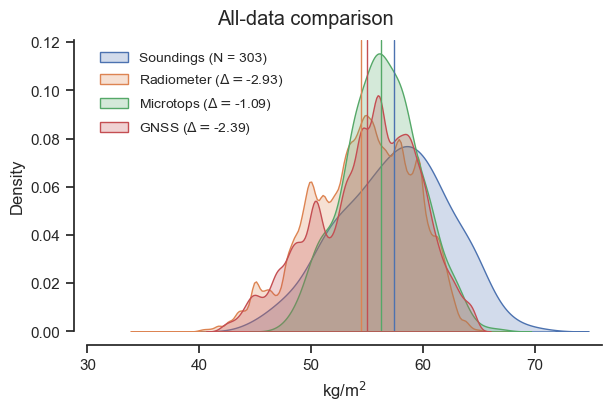

In [89]:
cwvs = [
    cwv_meteor[t_ind_snd],
    # cwv_pint_sh[t_ind_snd],
    cwv_rdm[t_ind_rdm],
    photom[t_ind_photom],
    cwv_gps[t_ind_gps],
    # cwv_era5v1[t_ind_era5v1],
    # cwv_era5v2[t_ind_era5v2],
]

legends = [
    'Soundings',
    # 'Soundings-SH',
    'Radiometer',
    'Microtops',
    'GNSS',
    # 'ERA5-track',
    # 'ERA5-sonde'
    ]

plot_cwv_kde(legends, cwvs, title='All-data comparison')

#### Filter by cloud/rain conditions

In [25]:
cm_meteor = interpolate_cloud_mask(times_cloud_mask, cloud_mask, snd_meteor['times'])
cm_rdm = interpolate_cloud_mask(times_cloud_mask, cloud_mask, times_rdm)
cm_photom = interpolate_cloud_mask(times_cloud_mask, cloud_mask, times_photom)
cm_gps = interpolate_cloud_mask(times_cloud_mask, cloud_mask, times_gps)
# cm_era5v2 = interpolate_cloud_mask(times_cloud_mask, cloud_mask, times_sonde_era5)

  0%|          | 0/322 [00:00<?, ?it/s]

  0%|          | 0/2713846 [00:00<?, ?it/s]

  0%|          | 0/635 [00:00<?, ?it/s]

  0%|          | 0/117246 [00:00<?, ?it/s]

  0%|          | 0/308 [00:00<?, ?it/s]

In [26]:
# Cloud mask conditions:
# From Anna:
# 1 = Clear sky
# 2 = probably cloudy
# 3 = confidently cloudy
# 4 = rain
# So it would be interesting to only use clear sky cases. Or at least non-rainy cases. Cloudy conditions are defined into porbably (when either ceilometer or cloud radar detected a signal) and confidentally cloudy (when both instruments detected a signal). the Probably cloduy situation mostly occured when there were thin liwuid clodus between 4 and 7 km - mostly the radar didnt see these, but the ceilometer could detect a clodu base. 

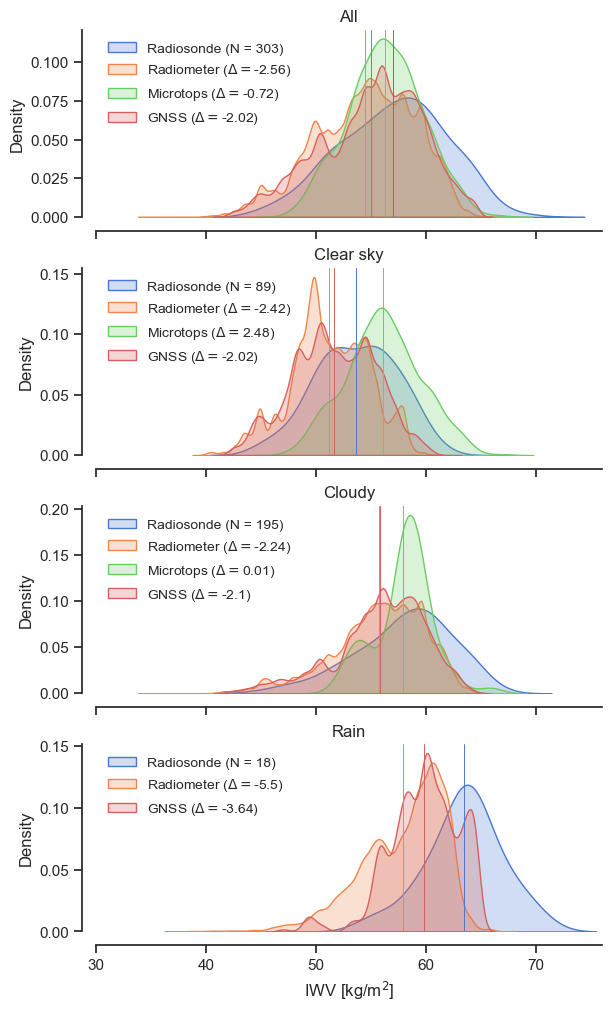

In [90]:
cwv_meteor_select = cwv_meteor_30m
# cwv_meteor_select = cwv_meteor

cwvs_all = [
    cwv_meteor_select[t_ind_snd],
    cwv_rdm[t_ind_rdm],
    photom[t_ind_photom],
    cwv_gps[t_ind_gps],
    # cwv_era5v2[t_ind_era5v2],
]

i_cloud_mask = 1
cm_tag2 = 'Clear sky'
cwvs_cs = [
    cwv_meteor_select[t_ind_snd][np.where(cm_meteor[t_ind_snd] == i_cloud_mask)],
    cwv_rdm[t_ind_rdm][np.where(cm_rdm[t_ind_rdm] == i_cloud_mask)],
    (photom[t_ind_photom])[np.where(cm_photom[t_ind_photom] == i_cloud_mask)],
    cwv_gps[t_ind_gps][np.where(cm_gps[t_ind_gps] == i_cloud_mask)],
    # cwv_era5v2[t_ind_era5v2][np.where(cm_era5v2[t_ind_era5v2] == i_cloud_mask)],
]

# i_cloud_mask = 2
cm_tag3 = 'Cloudy'
cwvs_cloudy = [
    cwv_meteor_select[t_ind_snd][np.where((cm_meteor[t_ind_snd] == 2) | (cm_meteor[t_ind_snd] == 3))],
    cwv_rdm[t_ind_rdm][np.where((cm_rdm[t_ind_rdm] == 2) | (cm_rdm[t_ind_rdm] == 3))],
    (photom[t_ind_photom])[np.where((cm_photom[t_ind_photom] == 2) | (cm_photom[t_ind_photom] == 3))],
    cwv_gps[t_ind_gps][np.where((cm_gps[t_ind_gps] == 2) | (cm_gps[t_ind_gps] == 3))],
    # cwv_era5v2[t_ind_era5v2][np.where((cm_era5v2[t_ind_era5v2] == 2) | (cm_era5v2[t_ind_era5v2] == 3))],
]

i_cloud_mask = 4
cm_tag4 = 'Rain'
cwvs_rain = [
    cwv_meteor_select[t_ind_snd][np.where(cm_meteor[t_ind_snd] == i_cloud_mask)],
    cwv_rdm[t_ind_rdm][np.where(cm_rdm[t_ind_rdm] == i_cloud_mask)],
    (photom[t_ind_photom])[np.where(cm_photom[t_ind_photom] == i_cloud_mask)],
    cwv_gps[t_ind_gps][np.where(cm_gps[t_ind_gps] == i_cloud_mask)],
    # cwv_era5v2[t_ind_era5v2][np.where(cm_era5v2[t_ind_era5v2] == i_cloud_mask)],
]

cwvs_nested = [cwvs_all, cwvs_cs, cwvs_cloudy, cwvs_rain]
cm_tags = ['All', cm_tag2, cm_tag3, cm_tag4]

legends = [
    'Radiosonde',
    'Radiometer',
    'Microtops',
    'GNSS',
    # 'ERA5-sonde'
    ]

plot_cwv_kde_cm(legends, cwvs_nested, cm_tags)

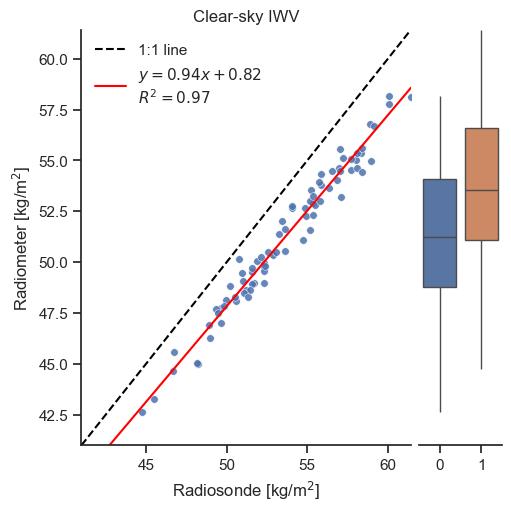

In [196]:
# Plot the scatter of cwv_meteor_select vs. cwv_rdm
def plot_scatter_cwv_meteor_vs_rdm(cwv_meteor, cwv_rdm):
    # Plot scatter plot of CWV from soundings vs. radiometer.
    sns.set_theme(style="ticks", rc={'xtick.bottom': True, 'ytick.left': True, "axes.spines.right": False, "axes.spines.top": False})
    fig_x = 5
    fig_y = 5
    fig, axs = plt.subplots(1, 2, figsize=(fig_x, fig_y), width_ratios=[0.8, 0.2],
                            layout='constrained', squeeze=True)
    # axs[0].set_aspect('equal')
    axs[0].set_xlabel('Radiosonde [kg/m$^2$]')
    axs[0].set_ylabel('Radiometer [kg/m$^2$]')
    axs[0].set_title('Clear-sky IWV')
    sns.scatterplot(x=cwv_meteor, y=cwv_rdm, ax=axs[0], s=30, alpha=0.85)
    # Plot the 1:1 line
    max_val = np.nanmax([np.nanmax(cwv_meteor), np.nanmax(cwv_rdm)])
    min_val = 41#np.nanmin([np.nanmin(cwv_meteor), np.nanmin(cwv_rdm)])
    axs[0].set_xlim(min_val, max_val)
    axs[0].set_ylim(min_val, max_val)
    axs[1].set_ylim(min_val, max_val)
    axs[0].plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', label='1:1 line')
    # Plot the regression line
    # use scipy
    from scipy.stats import linregress
    slope, intercept, r_value, p_value, std_err = linregress(cwv_meteor, cwv_rdm)
    x_fit = np.linspace(min_val, max_val, 100)
    y_fit = slope * x_fit + intercept
    axs[0].plot(x_fit, y_fit, color='red', label='$y = {:.2f}x + {:.2f}$\n$R^2 = {:.2f}$'.format(slope, intercept, r_value**2))
    # Add a legend
    axs[0].legend(frameon=False)
    # sns.despine(offset=10, ax=ax) # Remove top and right spines

    # Add second panel with boxplots of both variables
    sns.boxplot(data=[cwv_rdm, cwv_meteor], ax=axs[1], showcaps=False,
                meanprops={"marker":"o", "markerfacecolor":"white",
                           "markeredgecolor":"black", "markersize":"6"})
    # Remove y-axis from the second panel
    sns.despine(ax=axs[1], left=True)
    axs[1].set(yticklabels=[])
    axs[1].tick_params(left=False)

    plt.show()
    plt.close()
    return None

# Interpolates the cloud mask to match the times of the input soundings.
def interpolate_nearest(times_in, times_out, var):
    var_interp = np.full(len(times_out), np.nan)
    for itime in range(len(times_out)):
        time_diff = np.abs(times_in.astype('datetime64[ns]') - times_out[itime].astype('datetime64[ns]'))
        closest_index = np.argmin(time_diff)
        var_interp[itime] = var[closest_index]
    return var_interp

i_cloud_mask = 1
cwv_meteor_cs = cwv_meteor_select[t_ind_snd][np.where(cm_meteor[t_ind_snd] == i_cloud_mask)]

# Use nearest-neighbor interpolation to match the times of the radiometer data to the soundings
cwv_rdm_cs = cwv_rdm[t_ind_rdm][np.where(cm_rdm[t_ind_rdm] == i_cloud_mask)]
times_interp = snd_meteor['times'][t_ind_snd][np.where(cm_meteor[t_ind_snd] == i_cloud_mask)]
times_rdm_interp = times_rdm[t_ind_rdm][np.where(cm_rdm[t_ind_rdm] == i_cloud_mask)]
cwv_rdm_cs_meteortimes = interpolate_nearest(times_rdm_interp, times_interp, cwv_rdm_cs)

# Find mutually finite indices
ind_finite = np.isfinite(cwv_meteor_cs*cwv_rdm_cs_meteortimes)

plot_scatter_cwv_meteor_vs_rdm(cwv_meteor_cs[ind_finite].filled(), cwv_rdm_cs_meteortimes[ind_finite])

#### Compare two ERA5 datasets

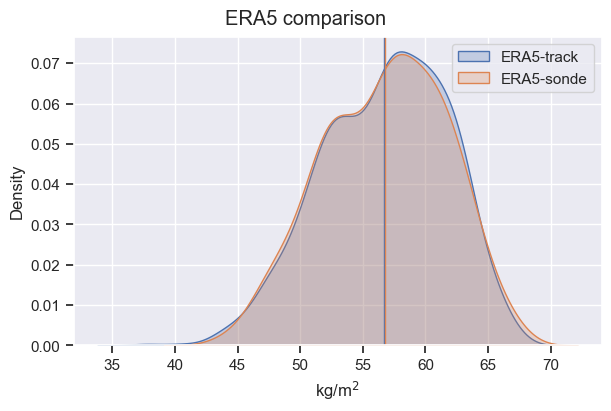

In [23]:
legends = ['ERA5-track', 'ERA5-sonde']
cwvs = [cwv_era5v1[t_ind_era5v1], cwv_era5v2[t_ind_era5v2]]
plot_cwv_kde(legends, cwvs, title='ERA5 comparison')

#### Compare Meteor and HALO sondes

Mean CWV for Meteor : 57.115 kg/m^2
Mean CWV for HALO : 51.791 kg/m^2
Difference between means: 5.324 kg/m^2


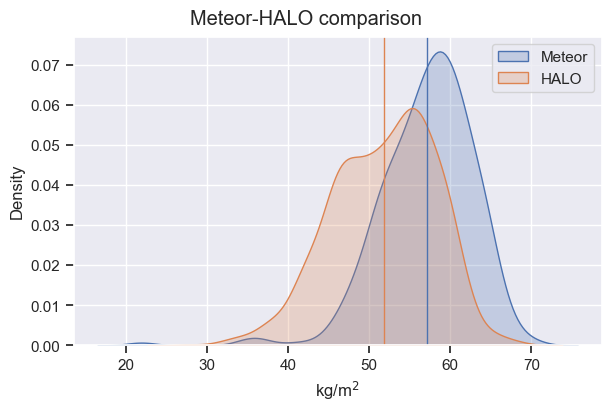

In [24]:
legends = ['Meteor', 'HALO']#, 'HALO-readIWV']
cwvs = [cwv_meteor, cwv_halo]#, snd_halo['iwv']]
plot_cwv_kde(legends, cwvs, title='Meteor-HALO comparison')
mean_comparison(cwvs, legends)

##### Find time/loc matches

##### Map sonde locations

In [91]:
def get_density(p, t, mr):
    rd=287.04
    rv=461.5
    eps_r=rv/rd
    return p / ( rd * t * (1. + mr*eps_r)/(1.+mr) )

def calc_cwv_local(p, t, mr, hght, p_min=0):
    # Remove NaNs
    p = pd.Series(p).interpolate(method='linear').to_numpy()
    t = pd.Series(t).interpolate(method='linear').to_numpy()
    mr = pd.Series(mr).interpolate(method='linear').to_numpy()
    # Find non-nan values
    sh = mixr2sh(mr)
    rho = get_density(p, t, mr)
    iz_max = 1 + np.max(np.where(p >= p_min*1e2))
    cwv = np.nansum((rho[:iz_max] * sh[:iz_max] * np.gradient(hght[:iz_max])))
    return cwv, mr[:iz_max], p[:iz_max]

In [107]:
def plot_qv_comparison(mr_meteor, mr_matches_halo, p_meteor, p_halo, cwv_meteor, cwv_halo):
    ax = plt.figure(figsize=(6, 5))
    plt.title('Mixing Ratio')
    plt.ylabel('Pressure [hPa]')
    plt.xlabel('$r_v$ [g/kg]')
    plt.plot(mr_meteor*1e3, p_meteor*1e-2, 'r', linewidth=1.0, label='Meteor ('+str(np.round(cwv_meteor,2))+')')
    nprof = len(mr_matches_halo)
    for iprof in range(nprof):
        plt.plot(mr_matches_halo[iprof]*1e3, p_halo[iprof]*1e-2, 'b', linewidth=0.8+0.4*iprof, label='HALO ('+str(np.round(cwv_halo[iprof],2))+')')
    # Set log axis
    # plt.xscale('log')
    plt.ylim(1000, 200)
    # plt.plot(pltvar_meteor*np.nan, p_meteor*1e-2, 'k', linewidth=1.0, label='C-Diff')
    plt.legend()
    # Create new x-axis
    # plt.twiny()
    # plt.xscale('linear')
    # plt.xlabel('Cumulative difference')
    # plt.plot(pltvar*0, p_meteor*1e-2, 'k', linewidth=0.5, label='C-Diff')
    # plt.plot(pltvar, p_meteor*1e-2, 'k', linewidth=1.5, label='C-Diff')
    # plt.ylim(1000, 100)
    plt.show()
    plt.close()
    return None

In [137]:
def plot_sonde_locations(snd_meteor, snd_halo, it_meteor_sav, it_halo_sav, title=''):
    import matplotlib.pyplot as plt
    from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
    import cartopy
    # create figure
    fig = plt.figure(figsize=(12,7))
    proj = cartopy.crs.PlateCarree()#central_longitude=offset)
    ax = fig.add_subplot(111,projection=proj)
    # set title
    plt.title(title)
    # add map features
    ax.add_feature(cartopy.feature.LAND,facecolor="lightgray") #land color
    # ax.add_feature(cartopy.feature.OCEAN) #ocean color
    ax.add_feature(cartopy.feature.COASTLINE)
    # ax.add_feature(cartopy.feature.STATES)
    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
        xlocs=np.arange(-60,-10,5), ylocs=np.arange(-10,20,5))
    # select plotting area
    lonMin, lonMax = -61, -20
    latMin, latMax = -0, 17
    plt_area=[lonMin, lonMax, latMin, latMax] # W,E,S,N
    ax.set_extent(plt_area)
    # Plot comparison sonde locations
    markersize = 3
    for imatch in range(len(it_meteor_sav)):
        # Plot Meteor
        ax.plot(snd_meteor['lon'][it_meteor_sav[imatch]], snd_meteor['lat'][it_meteor_sav[imatch]], 'o', color='red', markersize=markersize, label='Meteor', alpha=0.4)
    for imatch in range(len(it_halo_sav)):
        # Plot HALO
        ax.plot(snd_halo['lon'][it_halo_sav[imatch]], snd_halo['lat'][it_halo_sav[imatch]], 'o', color='blue', markersize=markersize, label='HALO', alpha=0.4)
    # plt.legend(loc="upper right")
    plt.show()
    plt.close()
    return None

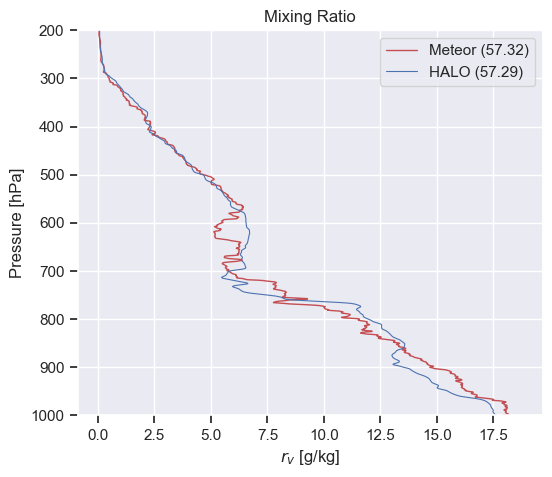

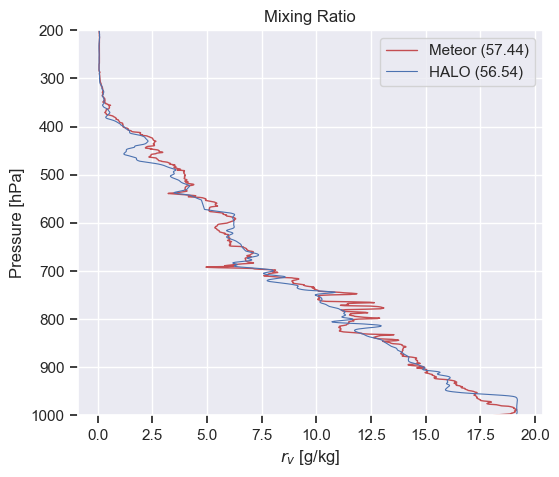

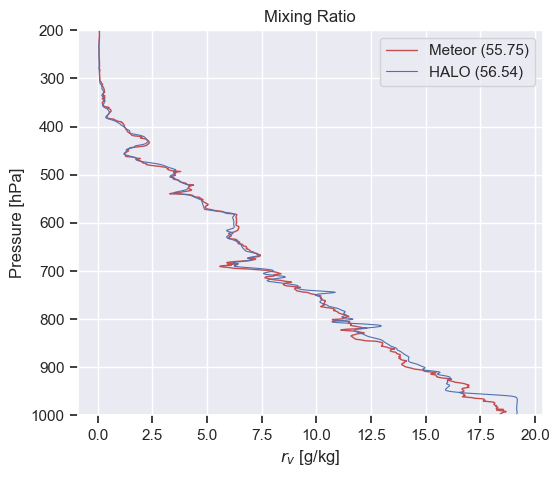

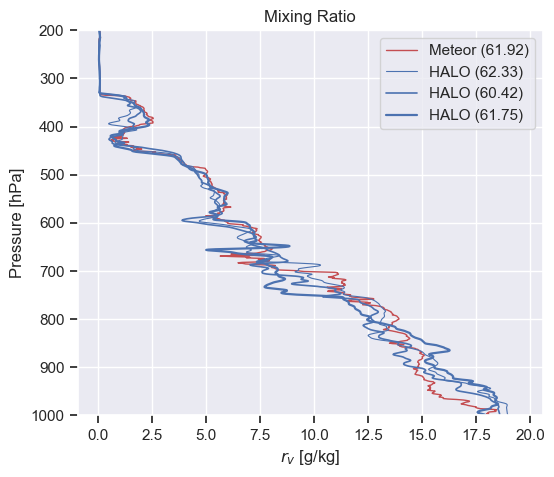

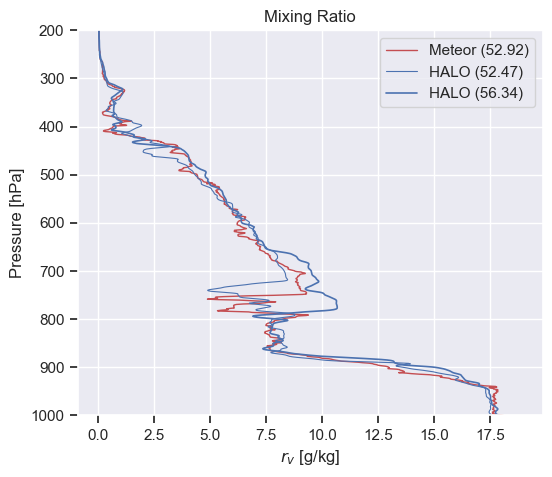

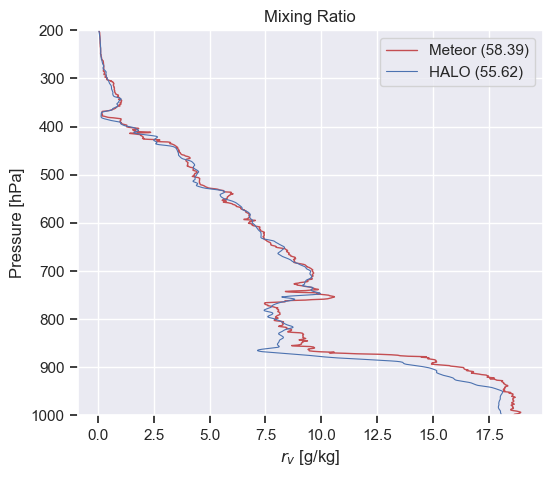

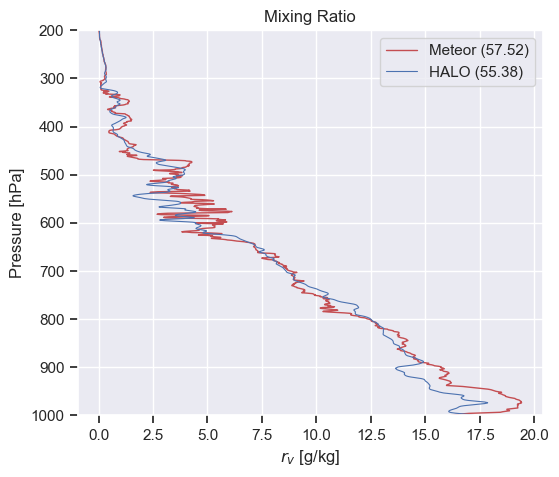

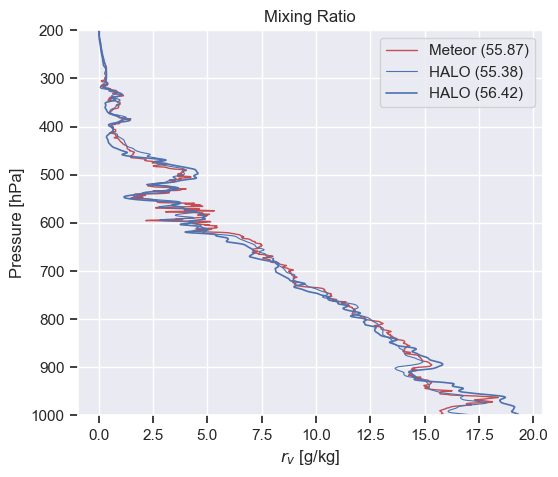

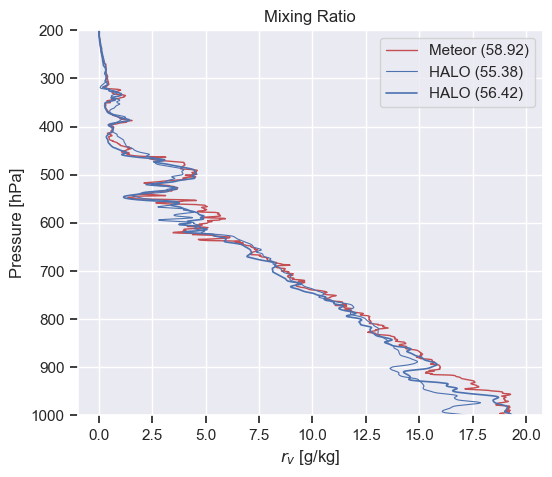

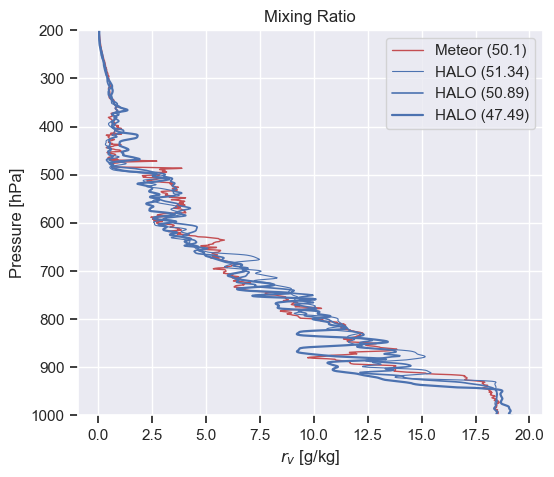

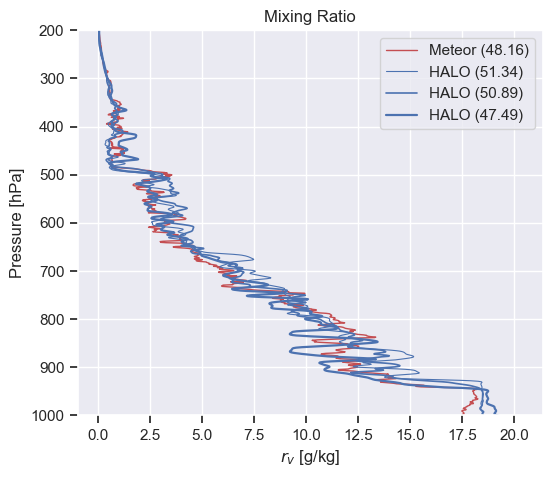

Number of matches, Meteor: 11
Number of matches, HALO: 20



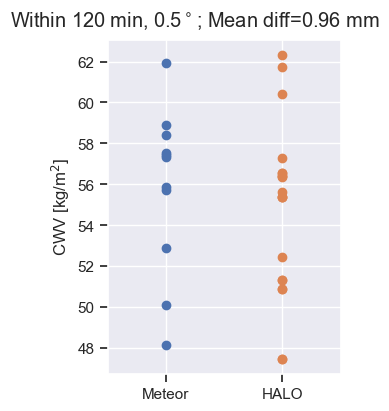

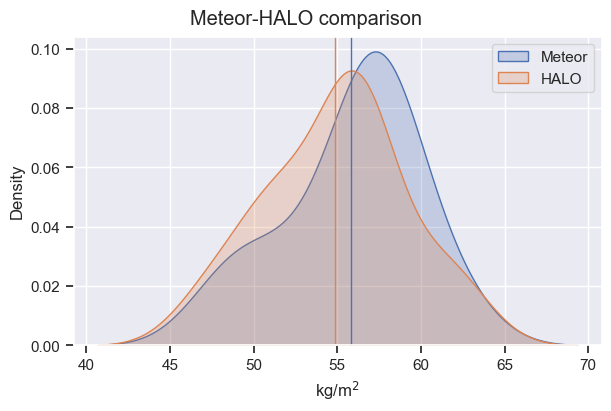

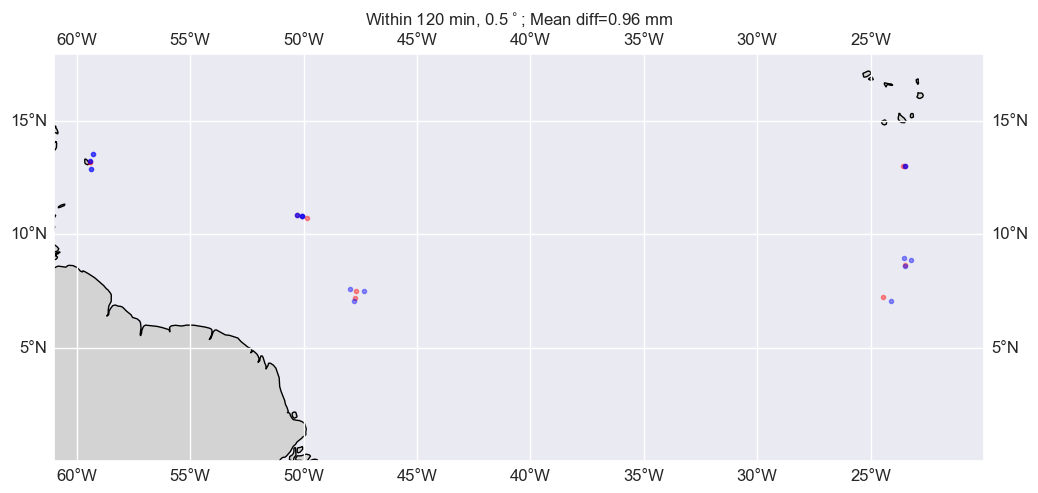

In [149]:
# Isolate neighboring sondes in time & space
maxdiff_latlon = 0.5 # deg
# maxdiff_latlon = 0.25 # deg
nmin_diff=120
# nmin_diff=30
maxdiff_time = np.timedelta64(nmin_diff, 'm') # minutes
nt_meteor = len(snd_meteor['times'])
cwv_matches = {}
cwv_matches['meteor'] = []
cwv_matches['halo'] = []
meteor_times = []
it_meteor_sav = []
halo_times = []
it_halo_sav = []
for isnd_meteor in range(nt_meteor):
    # Check for completeness
    n_valid = np.sum(np.isfinite(snd_meteor['p'][isnd_meteor,:]))
    if n_valid/1500 < 0.7:
        continue
    itime_meteor = snd_meteor['times'][isnd_meteor]
    ilat_meteor = snd_meteor['lat'][isnd_meteor]
    ilon_meteor = snd_meteor['lon'][isnd_meteor]
    match_halo_time = np.where(np.abs(itime_meteor - snd_halo['times']) <= maxdiff_time)[0]
    latdiff = np.abs(ilat_meteor - snd_halo['lat'][match_halo_time])
    londiff = np.abs(ilon_meteor - snd_halo['lon'][match_halo_time])
    match_halo_latlon = np.where(np.sqrt(latdiff**2 + londiff**2) <= maxdiff_latlon)[0]
    if match_halo_latlon.size > 0:
        meteor_times.append(itime_meteor)
        it_meteor_sav.append(isnd_meteor)
        p = snd_meteor['p'][isnd_meteor,:]
        t = snd_meteor['tmpk'][isnd_meteor,:]
        mr = snd_meteor['mr'][isnd_meteor,:]
        cwv_local_meteor, mr_meteor, p_meteor = calc_cwv_local(p, t, mr, snd_meteor['hght'], p_min=200)
        # cwv_matches['meteor'].append(cwv_meteor[isnd_meteor])
        cwv_matches['meteor'].append(cwv_local_meteor)
        mr_matches_halo = []
        p_halo = []
        cwv_local_halo = []
        for i_match in match_halo_latlon:
            isnd_halo = match_halo_time[i_match]
            halo_times.append(snd_halo['times'][isnd_halo])
            it_halo_sav.append(isnd_halo)
            p = snd_halo['p'][isnd_halo,:]
            # print('HALO p-min: ',np.nanmin(p))
            t = snd_halo['tmpk'][isnd_halo,:]
            mr = snd_halo['mr'][isnd_halo,:]
            icwv, mr_halo, p = calc_cwv_local(p, t, mr, snd_halo['hght'], p_min=200)
            cwv_local_halo.append(icwv)
            cwv_matches['halo'].append(icwv)
            mr_matches_halo.append(mr_halo)
            p_halo.append(p)
            # cwv_matches['halo'].append(cwv_halo[isnd_halo])
        plot_qv_comparison(mr_meteor, mr_matches_halo, p_meteor, p_halo,
                            cwv_local_meteor, cwv_local_halo)

# print('Meteor times:')
# print(np.array(meteor_times))
# print('HALO times:')
# print(np.array(halo_times))
# print()

# print('Meteor index matches:')
# print(np.array(it_meteor_sav))
# print('HALO index matches:')
# print(np.array(it_halo_sav))
# print()

cwv_matches['halo'] = np.array(cwv_matches['halo'])
cwv_matches['meteor'] = np.array(cwv_matches['meteor'])
n_matches_meteor = len(cwv_matches['meteor'])
print('Number of matches, Meteor:', n_matches_meteor)
n_matches_halo = len(cwv_matches['halo'])
print('Number of matches, HALO:', n_matches_halo)
# print('HALO: ',cwv_matches['halo'])
# print('Meteor: ',cwv_matches['meteor'])
print()
# Mean difference
mean_diff = np.abs(np.nanmean(cwv_matches['halo']) - np.nanmean(cwv_matches['meteor']))
# print('Mean difference:', mean_diff.round(3), 'kg/m^2')

# legends = ['Meteor', 'HALO ('+str(len(cwv_matches['halo']))+' matches)']
legends = ['Meteor', 'HALO']
cwvs = [cwv_matches['meteor'], cwv_matches['halo']]
title='Within '+str(nmin_diff)+' min, '+str(maxdiff_latlon)+'$^\circ$; Mean diff='+str(mean_diff.round(2))+' mm'
plot_var_scatter(legends, cwvs, xtitle='CWV [kg/m$^2$]', title=title, do_legend=False)

# Plot histogram
plot_cwv_kde(legends, cwvs, title='Meteor-HALO comparison')

# Plot map of locations
plot_sonde_locations(snd_meteor, snd_halo, it_meteor_sav, it_halo_sav, title=title)

##### SkewT comparisons

In [45]:
# legends = ['Meteor', 'HALO']
# soundings_plot = [snd_meteor, snd_halo]

# # plot_sounding_comparison(soundings_plot, t_ind, times, legends)
# for i_match in range(nmatches):

#     # Meteor
#     # snd_time = times_snd[t_ind_match[it]].astype('datetime64[m]').astype(str)
#     # title = legends[0]+', '+snd_time
#     # plot_sounding(soundings, t_ind_match[it], title)

#     # BCO
#     # snd_time = times_bco[t_ind_bco[it]].astype('datetime64[m]').astype(str)
#     # title = legends[1]+', '+snd_time
#     # plot_sounding(snd_bco, t_ind_bco[it], title)

#     snd_time = snd_meteor['times'][it_meteor_sav[i_match]].astype('datetime64[m]').astype(str)
#     title = snd_time
#     t_ind = [it_meteor_sav[i_match], it_halo_sav[i_match]]
#     plot_sounding_comparison(soundings_plot, t_ind, title)

### Compare BCO and Meteor sondes

In [28]:
# Select dates when Meteor was stationed next to BCO
# t_start = np.datetime64('2024-09-23T00:00:00')
t_start = np.datetime64('2024-09-22T20:00:00')
t_end = snd_meteor['times'][-1]
# t_ind_snd = np.where((times_snd >= t_start) & (times_snd <= t_end))[0]
t_ind_bco_nearby = np.where((snd_bco['times'] >= t_start) & (snd_bco['times'] <= t_end))[0]
# print(times_snd[t_ind_snd])
# print(times_bco[t_ind_bco])

In [29]:
# Identify matching times for Meteor and BCO within 1-hour window
t_ind_match = []
t_ind_bco = []
# delta = np.timedelta64(30, 'm') # 30 min
delta = np.timedelta64(60, 'm') # 60 min
# delta = np.timedelta64(90, 'm') # 60 min
for it in range(len(t_ind_bco_nearby)):
    t = snd_bco['times'][t_ind_bco_nearby[it]]
    t_ind = np.where((snd_meteor['times'] >= t - delta) & (snd_meteor['times'] <= t + delta))[0]
    if len(t_ind) > 0:
        # Check if nan
        if np.isnan(cwv_meteor[t_ind[0]]) or np.isnan(cwv_bco[t_ind_bco_nearby[it]]):
            continue
        t_ind_match.append(t_ind[0])
        t_ind_bco.append(t_ind_bco_nearby[it])
print(len(t_ind_match))

13


In [30]:
mean_cwv = np.nanmean(cwv_meteor[t_ind_match])
mean_cwv_bco = np.nanmean(cwv_bco[t_ind_bco])
print("Mean CWV Meteor: ", mean_cwv.round(2), 'kg/m^2')
print("Mean CWV BCO: ", mean_cwv_bco.round(2), 'kg/m^2')

Mean CWV Meteor:  50.12 kg/m^2
Mean CWV BCO:  50.63 kg/m^2


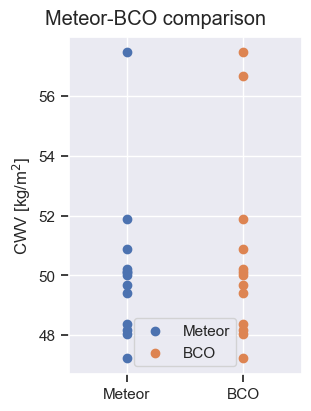

In [31]:
legends = ['Meteor', 'BCO']
cwvs = [cwv_meteor[t_ind_match], cwv_bco[t_ind_bco]]
# cwvs = [cwv_17m[t_ind_match], cwv_bco[t_ind_bco]]
plot_var_scatter(legends, cwvs, xtitle='CWV [kg/m$^2$]', title='Meteor-BCO comparison')

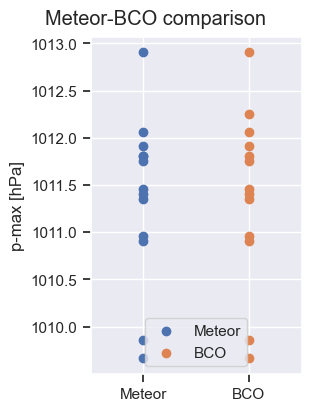

In [32]:
# Get time series of maximum sounding pressure
p_max = np.nanmax(snd_meteor['p'], axis=1)*1e-2
p_max_bco = np.nanmax(snd_bco['p'], axis=1)*1e-2

legends = ['Meteor', 'BCO']
pmax = [p_max[t_ind_match], p_max_bco[t_ind_bco]]
plot_var_scatter(legends, pmax, xtitle='p-max [hPa]', title='Meteor-BCO comparison')

#### Estimate the impact of BCO's elevation difference on CWV

In [33]:
dp = np.mean(p_max[t_ind_match]) - np.mean(p_max_bco[t_ind_bco])
print('Mean pressure difference: ', dp, 'hPa')

q = 0.017 # kg/kg
g = 9.81 # m/s2
dp = dp*1e2 # hPa --> Pa
dq = q*dp/g
print('CWV difference: ', dq, 'kg/m2')

Mean pressure difference:  -0.03441105769218211 hPa
CWV difference:  -0.005963180232080489 kg/m2


#### Plot SkewTs

/Users/jamesruppert/miniforge3/envs/plotting/lib/python3.10/site-packages/metpy/plots/skewt.py:370: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.2980392156862745, 0.4470588235294118, 0.6901960784313725, 1)). The keyword argument will take precedence.
  return self.ax.plot(t, pressure, *args, **kwargs)
/Users/jamesruppert/miniforge3/envs/plotting/lib/python3.10/site-packages/metpy/plots/skewt.py:370: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "c" (-> color=(0.39215686274509803, 0.7098039215686275, 0.803921568627451, 1)). The keyword argument will take precedence.
  return self.ax.plot(t, pressure, *args, **kwargs)


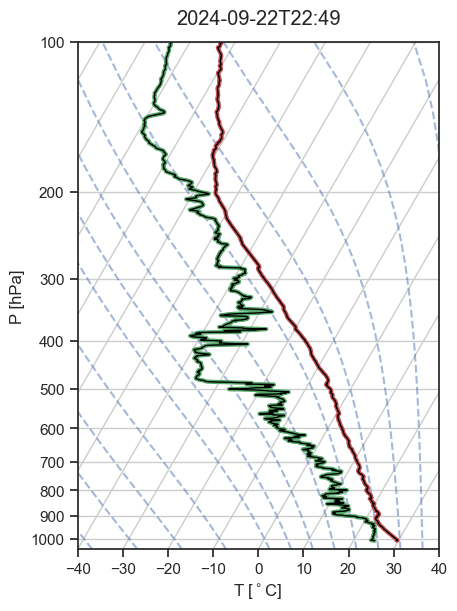

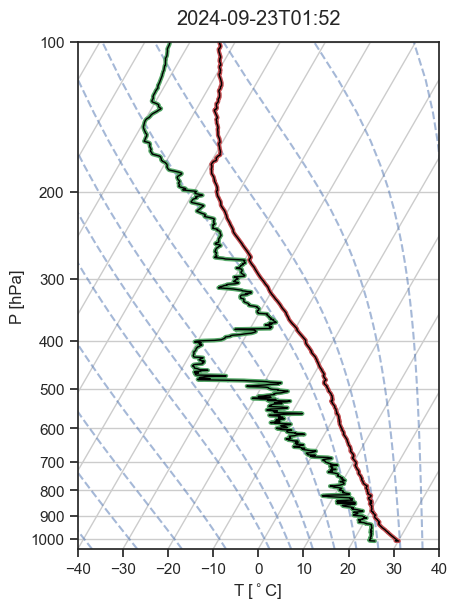

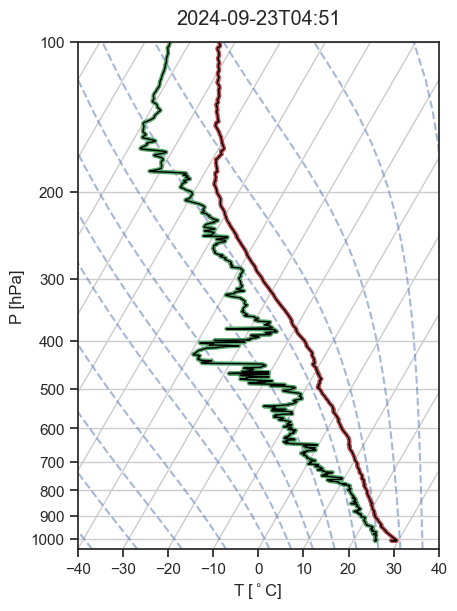

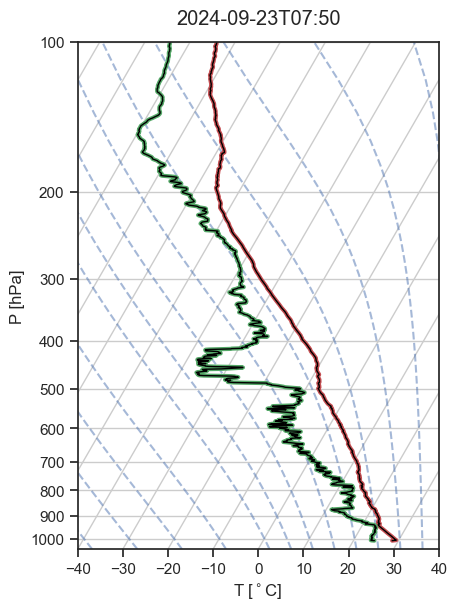

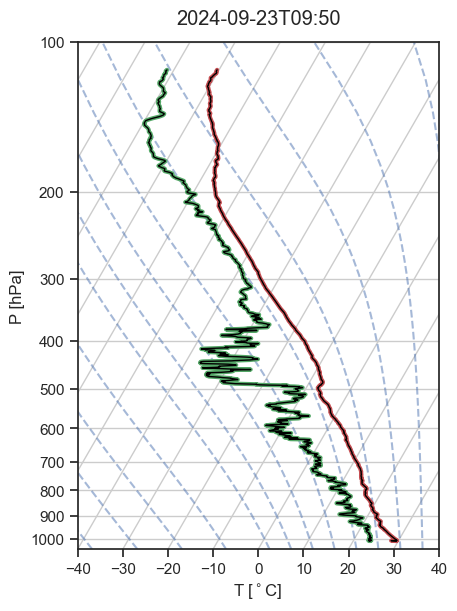

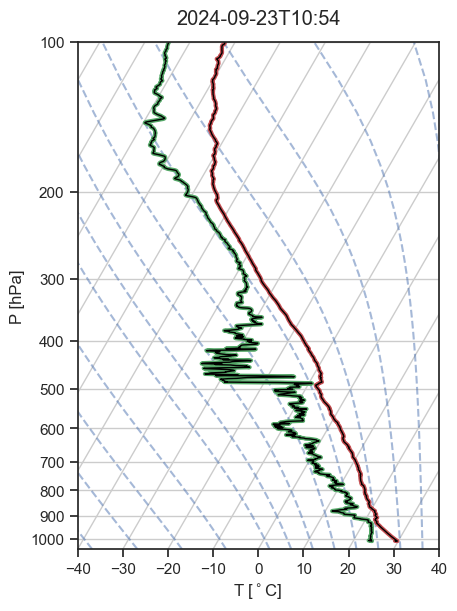

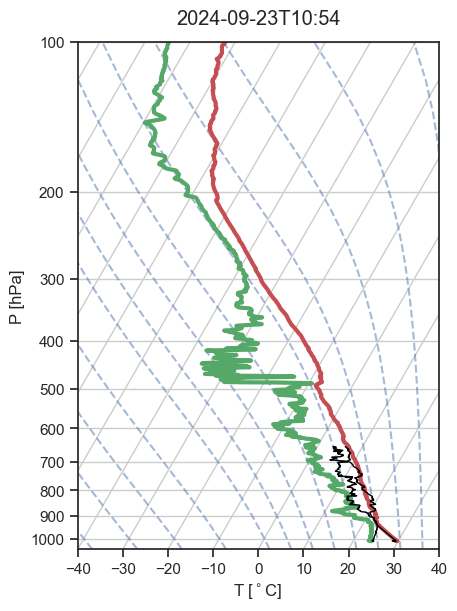

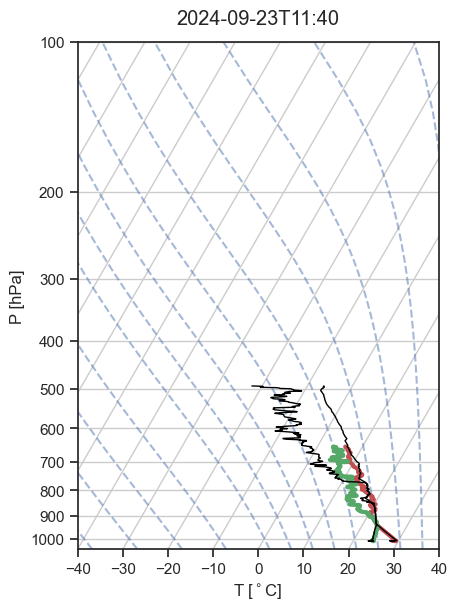

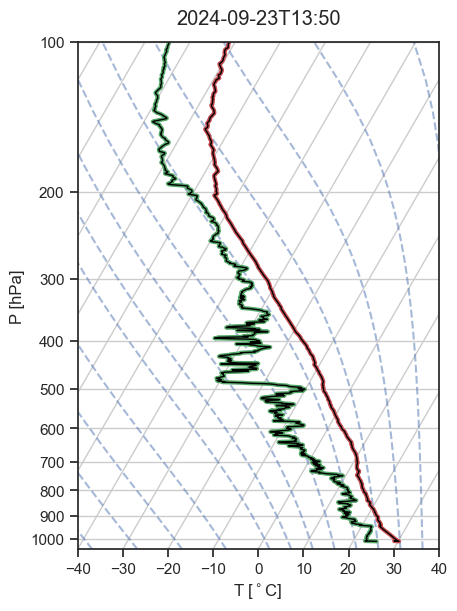

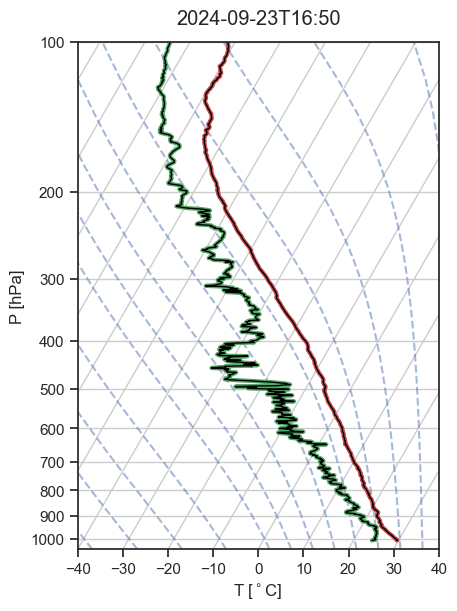

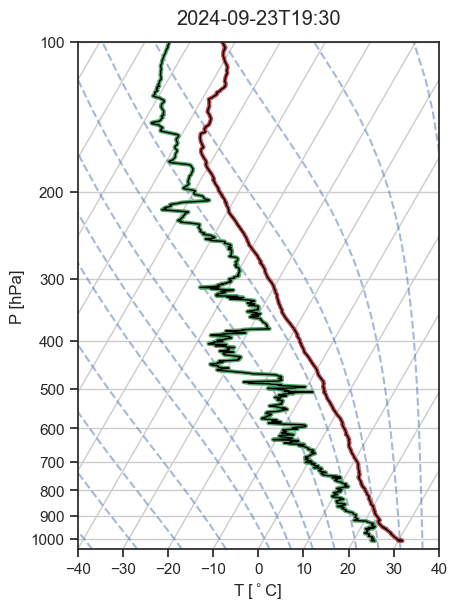

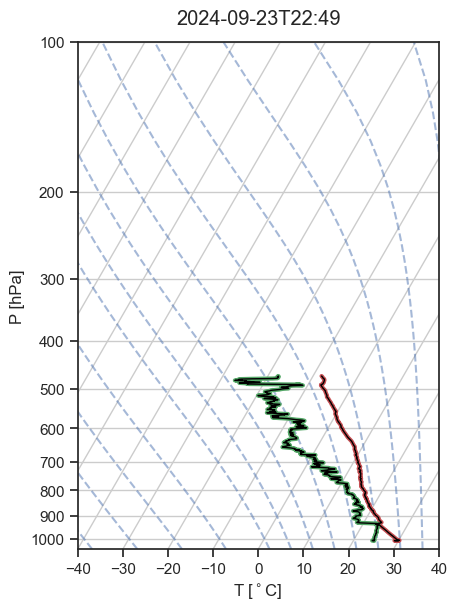

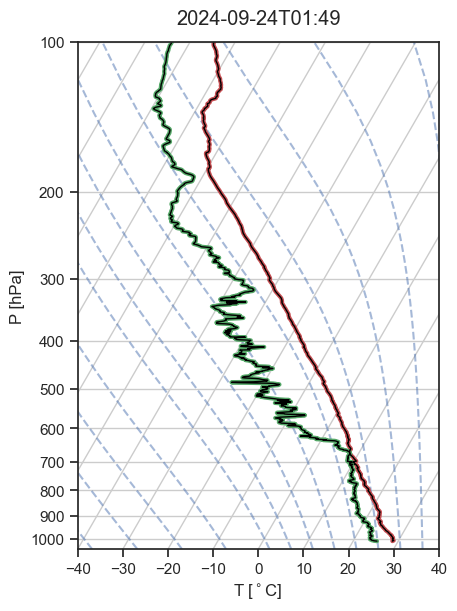

In [34]:
legends = ['Meteor', 'BCO']
soundings_plot = [snd_meteor, snd_bco]
# t_ind = [t_ind_match, t_ind_bco]
# times = [times_snd, times_bco]

# plot_sounding_comparison(soundings_plot, t_ind, times, legends)
for it in range(len(t_ind_match)):
# for it in range(1):

    # Meteor
    # snd_time = times_snd[t_ind_match[it]].astype('datetime64[m]').astype(str)
    # title = legends[0]+', '+snd_time
    # plot_sounding(soundings, t_ind_match[it], title)

    # # BCO
    # snd_time = times_bco[t_ind_bco[it]].astype('datetime64[m]').astype(str)
    # title = legends[1]+', '+snd_time
    # plot_sounding(snd_bco, t_ind_bco[it], title)

    snd_time = snd_meteor['times'][t_ind_match[it]].astype('datetime64[m]').astype(str)
    title = snd_time
    t_ind = [t_ind_match[it], t_ind_bco[it]]
    plot_sounding_comparison(soundings_plot, t_ind, title)